In [1]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np



In [2]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()
print("x_train shape",x_train.shape)
print("y_train shape",y_test.shape)
print("x_test shape",x_test.shape)
print("y_test shape",y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape (60000, 28, 28)
y_train shape (10000,)
x_test shape (10000, 28, 28)
y_test shape (10000,)


label: 2


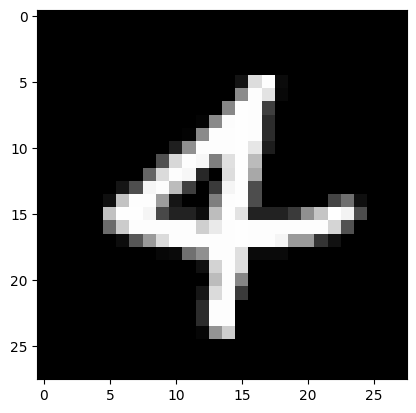

In [ ]:
#basic data visualization
img=x_train[150]
label=y_test[1]
print("label:",label)
plt.imshow(img,cmap='blue')
plt.show()

Data preprocessing

In [3]:
#normalize and reshape
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255
x_test=x_test.reshape(-1,28,28,1).astype('float')/255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [4]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from keras.src.backend.torch import optimizers
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2)
#epochs---->Model sees datasets 5 times
#batch_size =process 128 images per step

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.9326 - loss: 0.2301 - val_accuracy: 0.9774 - val_loss: 0.0778
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 119ms/step - accuracy: 0.9799 - loss: 0.0650 - val_accuracy: 0.9835 - val_loss: 0.0549
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9864 - loss: 0.0443 - val_accuracy: 0.9869 - val_loss: 0.0446
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 112ms/step - accuracy: 0.9889 - loss: 0.0344 - val_accuracy: 0.9868 - val_loss: 0.0463
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.9910 - loss: 0.0275 - val_accuracy: 0.9892 - val_loss: 0.0387


Model evaluation

In [6]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Test accuracy:",test_acc)
print("Test loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9912 - loss: 0.0289
Test accuracy: 0.9911999702453613
Test loss: 0.02885669469833374


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted classes: [7 2 1 0 4]
True classes: [7 2 1 0 4]


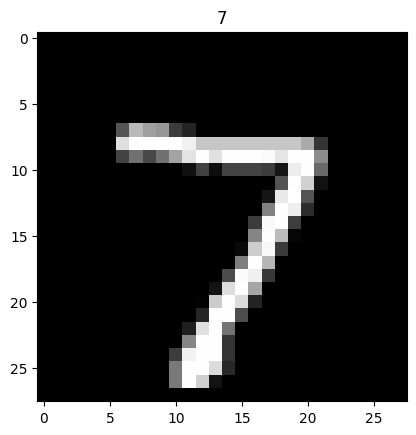

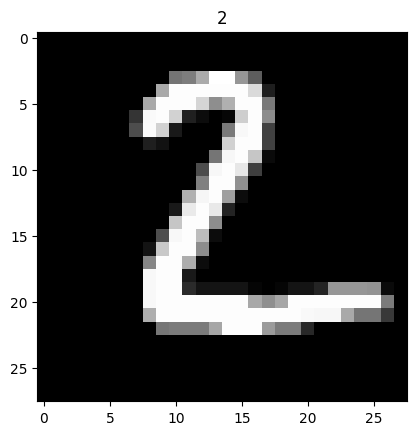

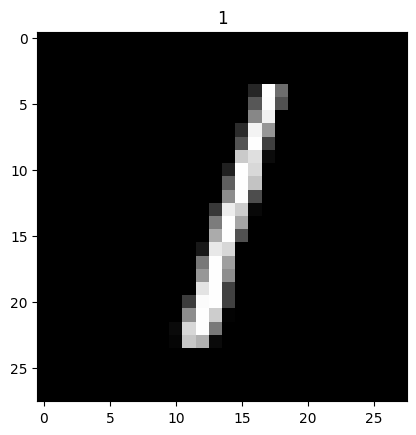

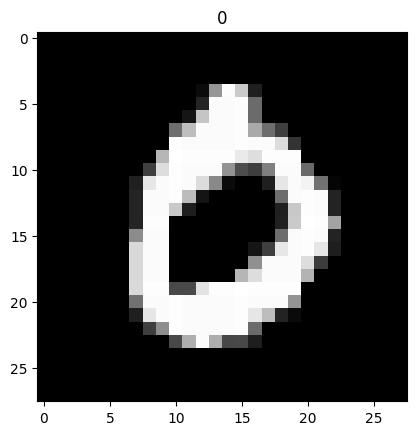

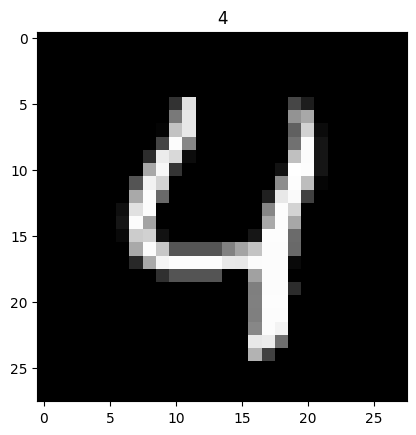

In [7]:
predictions = model.predict(x_test[ : 5])
predicted_classes = np.argmax(predictions, axis=1)
print("Predicted classes:", predicted_classes)
true_classess = np.argmax(y_test[ : 5], axis=1)
print("True classes:", true_classess)
for i in range(5):
  plt.imshow(x_test[i].reshape(28,28), cmap='gray')
  plt.title(predicted_classes[i])
  plt.show()